# Titanic

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
data = pd.read_csv('train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Limpieza de datos

Lo primero es ver la cantidad de datos nulos para ver si hay que eliminar alguna columna

In [98]:
# Cantidad de nulos por columna
nulos = data.isna().sum()
nulos

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Ahora hay que ver que porcentaje de nulos hay en cada columna

In [99]:
#total de elementos en cada columna, considerando los nulos
total = data.isna().count()    

#nulos dividido el total, multiplicado por 100 para obtener el porcentaje
porcentaje = (nulos / total) * 100      

#concatenamos los nulos y el porcentaje en un nuevo dataframe llamado datos_faltantes, con las columnas 'Nulos' y 'Porcentaje'
datos_faltantes = pd.concat([nulos, porcentaje], axis=1, keys=['Nulos', 'Porcentaje'])  

datos_faltantes

,Nulos,Porcentaje
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


Se eliminara la columna Cabin ya que su porcentaje de datos nulos es de un 77%

In [100]:
data = data.drop('Cabin', axis=1)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Como hay dos datos nulos en la Columna Embarked, simplemente se eliminan esas dos filas

In [101]:
data = data.dropna(subset=['Embarked'])
nulos = data.isna().sum()
nulos

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

Rellenar los datos de la columna Age con cero

In [102]:
#primero ver el valor maximo y minimo de la columna Age
edad_maxima = data['Age'].max()
edad_minima = data['Age'].min()

print(f'Edad maxima: {edad_maxima}, Edad minima: {edad_minima}')

#rellenar con 0
data['Age'] =data['Age'].fillna(0)
data.head()

Edad maxima: 80.0, Edad minima: 0.42


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Analisis exploratorio

### Promedio de cuantos sobrevivieron segun el sexo

In [113]:
promedio = data.groupby('Sex')['Survived'].mean()
print(promedio)

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64


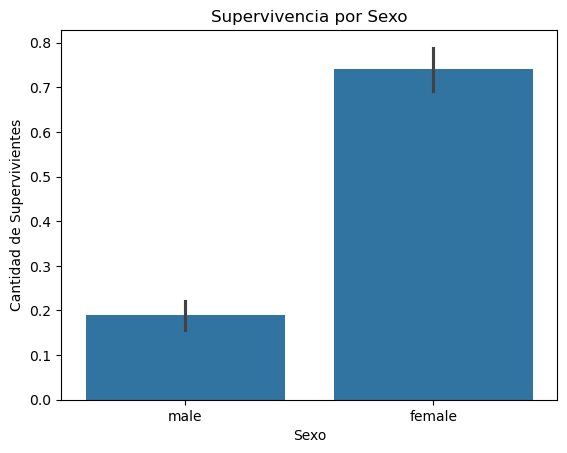

In [111]:
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Supervivencia por Sexo')
plt.ylabel('Cantidad de Supervivientes')
plt.xlabel('Sexo')
plt.show()

Se puede ver que sobreviveron mas mujeres que hombres, de la mujeres que estaban a bordo, sobrevivio un 74% mientras que en los hombres sobrevivieron un 18% aproximadamente

### Promedio de cuantos sobrevivieron segun la clase

In [115]:
clase = data.groupby('Pclass')['Survived'].mean()
print(clase)

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


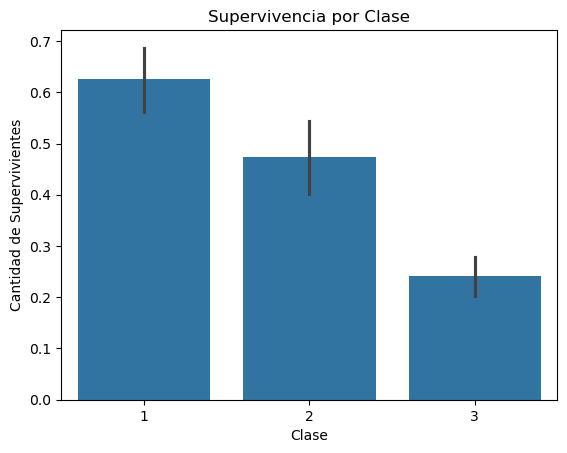

In [116]:
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Supervivencia por Clase')
plt.ylabel('Cantidad de Supervivientes')
plt.xlabel('Clase')
plt.show()

Sobrevivieron mas lo de primmera clase con un  62%, los de segunda clase sobrevivieron un 47% y los de tercera clase sobrevivieron con un 24%

### Supervivencia segun la clase y el sexo

In [119]:
probabilidad = data.groupby(['Sex', 'Pclass'])[['Survived']].mean()
prob = probabilidad.round(2)*100
print(prob)

               Survived
Sex    Pclass          
female 1           97.0
       2           92.0
       3           50.0
male   1           37.0
       2           16.0
       3           14.0


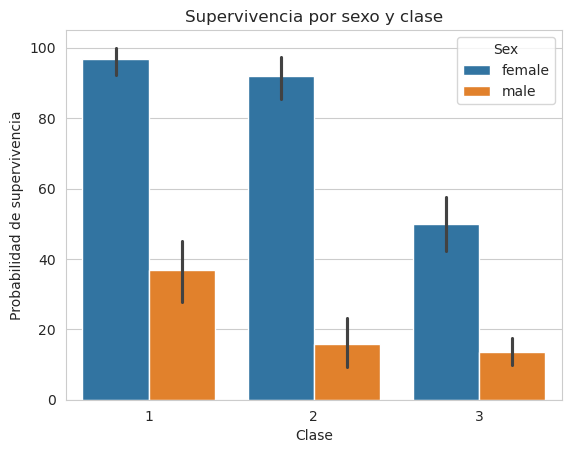

In [133]:
sns.barplot(x='Pclass', y=data['Survived'] * 100, data=data, hue='Sex')

plt.title("Supervivencia por sexo y clase")
plt.xlabel("Clase")
plt.ylabel("Probabilidad de supervivencia")

plt.show()

Se ve que en todas las clases, sobreviven as mujeres que hombres, sobretodo en la primera clase en la que sobrevivieron casi todas las mujeres

### Ver si viajaban solo o en familia

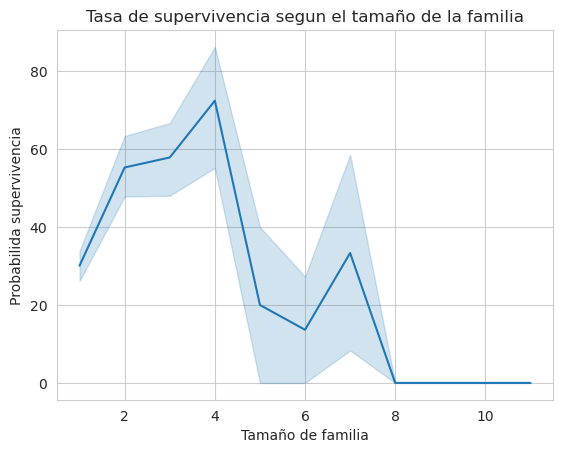

In [139]:
data['tamanoFamilia'] = data['SibSp'] + data['Parch'] + 1

sns.lineplot(x='tamanoFamilia', y=data['Survived']*100, data=data)
plt.title('Tasa de supervivencia segun el tamaño de la familia')
plt.xlabel("Tamaño de familia")
plt.ylabel("Probabilida supervivencia")
plt.show()

Las familias mas grande sobreviven menos, eso podria ser porque en el momento del accidente perdian tiempo buscandose entre si,, a diferencia de las familia mas chicas que podian arrancar mas rapido

### Mapa de calor

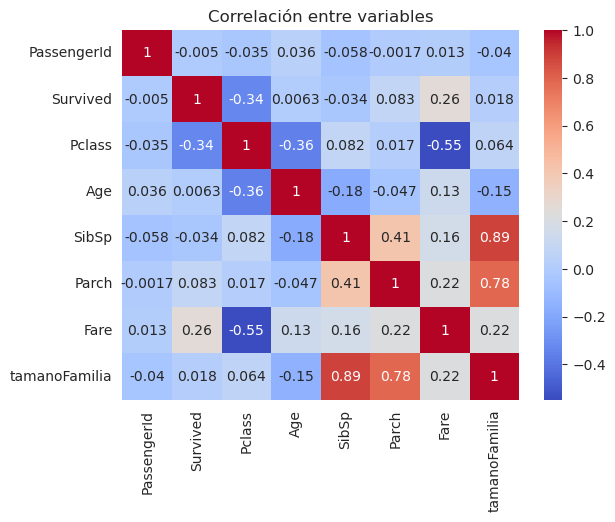

In [ ]:
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlacion entre las variables numericas')
plt.show()

En este grafico se pueden ver las variables mas relacionadas, las variables con correlacion positiva son las msa significantes, si una sube la otra igual, en cambio, las variables que tienen una correlacion negativa son opuestas, si una sube la tra baja y viceversa.

### Supervivencia segun el embarque

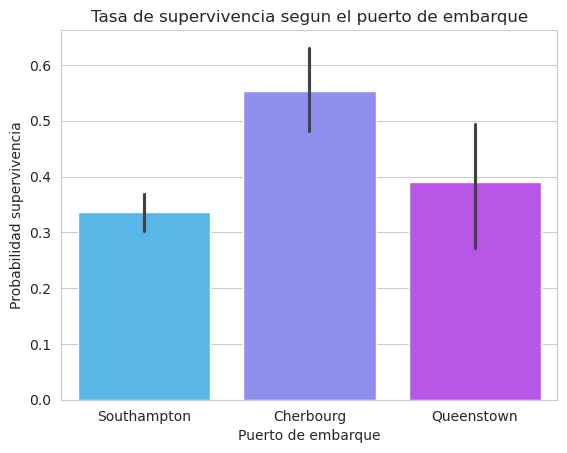

In [155]:
puertos = {
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'S': 'Southampton'
}

data['Embarked'] = data['Embarked'].map(puertos)

sns.barplot(x='Embarked', y='Survived', data=data, palette='cool', hue='Embarked')
plt.title('Tasa de supervivencia segun el puerto de embarque')
plt.xlabel("Puerto de embarque")
plt.ylabel("Probabilidad supervivencia")
plt.show()

Los que subieron al titanic en el puerto de Cherbourg tienen una probabilidad de sobrevivir mas alta que los demas, eso se podria deber a que quizas en ese puerto subieron todos los de clase mas alta